# Energy Sector Next-Day Movement Prediction

Final project — Fintech Workshop, Reichman University.

**Task:** binary classification — will an S&P 500 Energy stock rise more than 1% the next trading day?
**Prediction time:** daily at 4 PM market close.
**Dataset window:** through March 6, 2026.

Non-negotiable rules (from `CLAUDE.md`):
- No `train_test_split` — use roll-forward expanding window for time series.
- No look-ahead bias — every feature must use only data available by 4 PM on the prediction date.

# Stage 1 — Data Collection & Verification

This section covers Task 1.1 from `tasks/STAGE_1.md`: confirm the base dataset is complete and clean, and produce the data-overview numbers required by Stage 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Project-wide constants (kept at the top so they're easy to change later).
DATA_PATH = Path('../Data/sp500_Energy_dataset.csv')
THRESHOLD = 0.01  # 1% next-day return — confirmed with professor (used in Task 1.2)
EXPECTED_END_DATE = pd.Timestamp('2026-03-06')

pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 120)

## 1. Load the CSV

Date format in the source file is European (`DD/MM/YYYY`) — `dayfirst=True` is required or pandas silently misparses.

In [2]:
df = pd.read_csv(DATA_PATH, dayfirst=True, parse_dates=['date'])
df.head()

,date,ticker,sector,open,high,low,close,volume,daily_return_pct,1_d_return,vix_end_of_day,sp500_return_today
0,2022-03-29,APA,Energy,38.880,40.97,38.520,40.96,7534484.0,2.785445,0.59%,18.900000,1.225655
1,2022-03-30,APA,Energy,41.450,42.36,40.680,41.20,9015751.0,0.585938,0.32%,19.330000,-0.629370
2,2022-03-31,APA,Energy,41.060,42.77,40.800,41.33,7934454.0,0.315534,2.15%,20.559999,-1.565254
3,2022-04-01,APA,Energy,41.415,42.69,41.415,42.22,5005443.0,2.153399,1.80%,19.629999,0.341022
4,2022-04-04,APA,Energy,43.000,43.69,42.270,42.98,6946894.0,1.800095,-3.00%,18.570000,0.809094


## 2. Shape and dtypes

In [3]:
print('Shape:', df.shape)
df.info()

Shape: (20929, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20929 entries, 0 to 20928
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                20929 non-null  datetime64[ns]
 1   ticker              20929 non-null  object        
 2   sector              20929 non-null  object        
 3   open                20929 non-null  float64       
 4   high                20929 non-null  float64       
 5   low                 20929 non-null  float64       
 6   close               20929 non-null  float64       
 7   volume              20929 non-null  float64       
 8   daily_return_pct    20929 non-null  float64       
 9   1_d_return          20929 non-null  object        
 10  vix_end_of_day      20929 non-null  float64       
 11  sp500_return_today  20929 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(3)
memory usage: 1.9+ MB


## 3. Ticker coverage

How many distinct tickers, and how evenly are they covered? A ticker with materially fewer rows than the rest probably entered or left the index during the window.

In [4]:
n_tickers = df['ticker'].nunique()
print(f'Unique tickers: {n_tickers}')

ticker_counts = df['ticker'].value_counts().sort_values(ascending=False)
print('\nRows per ticker:')
print(ticker_counts)

Unique tickers: 22

Rows per ticker:
APA     988
BKR     988
XOM     988
COP     988
CVX     988
DVN     988
EOG     988
EQT     988
FANG    988
HAL     988
KMI     988
MPC     988
OKE     988
OXY     988
PSX     988
SLB     988
TPL     988
TRGP    988
VLO     988
WMB     988
CTRA    961
EXE     208
Name: ticker, dtype: int64


In [5]:
# Flag tickers with materially fewer rows than the median.
median_rows = ticker_counts.median()
low_coverage = ticker_counts[ticker_counts < 0.9 * median_rows]
print(f'Median rows per ticker: {int(median_rows)}')
if len(low_coverage) == 0:
    print('No tickers with <90% of median coverage.')
else:
    print('\nTickers with <90% of median coverage (likely index entry/exit):')
    print(low_coverage)

Median rows per ticker: 988

Tickers with <90% of median coverage (likely index entry/exit):
EXE    208
Name: ticker, dtype: int64


## 4. Date range and trading days

Per the professor, the data should end on or near **March 6, 2026**. We flag any deviation.

In [6]:
min_date = df['date'].min()
max_date = df['date'].max()
n_trading_days = df['date'].nunique()

print(f'Date range: {min_date.date()} → {max_date.date()}')
print(f'Total unique trading days: {n_trading_days}')
print(f'Expected end date: {EXPECTED_END_DATE.date()}')

delta = (EXPECTED_END_DATE - max_date).days
if delta == 0:
    print('Max date matches expectation exactly.')
else:
    print(f'Max date differs from expectation by {delta} day(s).')

Date range: 2022-03-29 → 2026-03-06
Total unique trading days: 988
Expected end date: 2026-03-06
Max date matches expectation exactly.


## 5. Missing values

In [7]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing cells: {int(missing.sum())}')

Missing values per column:
date                  0
ticker                0
sector                0
open                  0
high                  0
low                   0
close                 0
volume                0
daily_return_pct      0
1_d_return            0
vix_end_of_day        0
sp500_return_today    0
dtype: int64

Total missing cells: 0


## 6. Tickers present per date

Plotting the count of tickers reporting on each date. Drops here indicate tickers entering or leaving the S&P 500 Energy sector during the window — useful context for Stage 2 EDA and for any roll-forward training that needs to handle uneven panel shape.

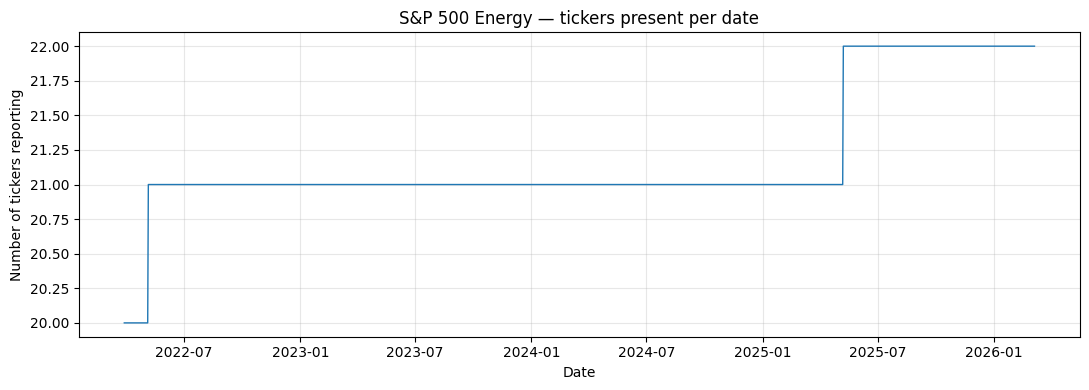

Min tickers on any date: 20
Max tickers on any date: 22
Most common count:     21


In [8]:
tickers_per_date = df.groupby('date')['ticker'].nunique().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tickers_per_date.index, tickers_per_date.values, linewidth=1.0)
ax.set_xlabel('Date')
ax.set_ylabel('Number of tickers reporting')
ax.set_title('S&P 500 Energy — tickers present per date')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f'Min tickers on any date: {tickers_per_date.min()}')
print(f'Max tickers on any date: {tickers_per_date.max()}')
print(f'Most common count:     {tickers_per_date.mode().iloc[0]}')

## 7. Findings summary

**Coverage.** The dataset has **20,929 rows × 12 columns** spanning **22 unique tickers** over **988 trading days** from **2022-03-29 to 2026-03-06**. The end date matches the professor's expectation exactly.

**Ticker balance.** 20 of the 22 tickers have the full 988 rows. Two have materially less coverage:
- **CTRA** — 961 rows (entered the panel a few weeks after the start).
- **EXE** — only 208 rows, well under the median. This is a recent addition to the S&P 500 Energy sector and is the lone ticker flagged by the <90% coverage check. Not a data quality bug, but we need to be aware when building per-ticker features in Stage 3 — short history can produce unstable rolling statistics.

**Panel shape.** Tickers reporting per date ranges from 20 to 22 (mode 21). The plot in section 6 shows the panel is not perfectly balanced — membership changes drive the step ups/downs. The roll-forward training loop in Stage 4 must handle uneven panel width without padding NaNs into features.

**Missing values.** Zero missing cells across all 12 columns. Note that the `1_d_return` column is currently a string with `%` suffix (dtype `object`) — that is expected and is cleaned in Task 1.2.

**Sector column.** All rows are labeled `Energy`, as expected.

**Conclusion.** Base dataset passes verification — proceed to Task 1.2 (binary label construction) and Task 1.4 (external Energy data sources).

# Stage 1 — Task 1.2: Binary label at 1% threshold

Goal: clean the `1_d_return` column into a numeric next-day return, justify the **confirmed 1% threshold** with a return-distribution analysis, and build the binary target.

Reminder: the **1% threshold is confirmed with the professor** — this task is about implementing it correctly, not relitigating the level.

## 1. Clean `1_d_return` and verify it really is the *next* day's return

From `df.info()` in Task 1.1, `1_d_return` is `object` dtype — strings like `'0.59%'`. Two things to do:
1. Strip the `%`, convert to float, divide by 100 to get a fractional return (`0.59% → 0.0059`).
2. Verify the semantics. If `1_d_return[t]` is genuinely the close-to-close return from day *t* to day *t+1*,    it should equal `daily_return_pct[t+1] / 100` for the **same ticker** on the next trading day.    If it doesn't, the column is mislabeled and we'd need to shift it ourselves.

In [9]:
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

df['next_day_return'] = (
    df['1_d_return']
      .str.rstrip('%')
      .astype(float)
      / 100.0
)

print(df[['date', 'ticker', 'close', 'daily_return_pct', '1_d_return', 'next_day_return']].head(6))
print()
print('next_day_return dtype:', df['next_day_return'].dtype)
print('next_day_return NaN count:', df['next_day_return'].isna().sum())

        date ticker  close  daily_return_pct 1_d_return  next_day_return
0 2022-03-29    APA  40.96          2.785445      0.59%           0.0059
1 2022-03-30    APA  41.20          0.585938      0.32%           0.0032
2 2022-03-31    APA  41.33          0.315534      2.15%           0.0215
3 2022-04-01    APA  42.22          2.153399      1.80%           0.0180
4 2022-04-04    APA  42.98          1.800095     -3.00%          -0.0300
5 2022-04-05    APA  41.69         -3.001396     -2.11%          -0.0211

next_day_return dtype: float64
next_day_return NaN count: 0


In [10]:
# Alignment check: next_day_return[t] for ticker T should equal daily_return_pct[t+1] / 100
# for that same ticker. We use groupby + shift(-1) so we never pull across tickers.
df['daily_return_next'] = df.groupby('ticker')['daily_return_pct'].shift(-1) / 100.0

# Compare on rows where the next-day value exists (i.e., not the last row per ticker)
mask = df['daily_return_next'].notna()
diff = (df.loc[mask, 'next_day_return'] - df.loc[mask, 'daily_return_next']).abs()

# 1_d_return is rounded to 2 decimals (e.g. '0.59%'), daily_return_pct is full precision.
# So mismatches up to ~0.005 (0.5 of a percent-point in the rounding) are expected.
tol = 0.005
mismatch = (diff > tol).sum()
print(f'Rows compared: {mask.sum():,}')
print(f'Max absolute diff: {diff.max():.6f}')
print(f'Median absolute diff: {diff.median():.6f}')
print(f'Rows exceeding {tol} tolerance: {mismatch}')
if mismatch == 0:
    print('\nVERIFIED: `1_d_return[t]` is the next-day return for the same ticker.')
else:
    print('\nWARNING: alignment check failed for some rows — inspect before trusting the label.')

Rows compared: 20,907
Max absolute diff: 0.000050
Median absolute diff: 0.000025
Rows exceeding 0.005 tolerance: 0

VERIFIED: `1_d_return[t]` is the next-day return for the same ticker.


### Last-day-per-ticker caveat

For each ticker, the last available date (typically **2026-03-06**) has a populated `next_day_return` value but no observable day *t+1* inside our panel. That label is technically a known forward value from the data vendor, but for any model trained on this window it is not a valid training row — we'd need an out-of-sample day to verify it. We **keep the value for now** (it's harmless for distribution analysis) and **drop or hold it out at modeling time** in Stage 4.

In [11]:
# Identify the last row per ticker — these are the rows whose `next_day_return` refers
# to a day outside our observed window.
last_idx = df.groupby('ticker')['date'].idxmax()
last_rows = df.loc[last_idx, ['ticker', 'date', 'next_day_return']].sort_values('date')
print(f'Last-row-per-ticker count: {len(last_rows)}')
print(last_rows.tail(10))

Last-row-per-ticker count: 22
      ticker       date  next_day_return
8084     EXE 2026-03-06          -0.0141
7876     EQT 2026-03-06           1.9075
6888     EOG 2026-03-06           1.3366
5900     DVN 2026-03-06           1.8962
4912     CVX 2026-03-06          -0.5531
3924    CTRA 2026-03-06           1.9884
2963     COP 2026-03-06           0.5620
1975     BKR 2026-03-06           0.2013
19940    WMB 2026-03-06          -0.3389
20928    XOM 2026-03-06          -0.4096


## 2. Distribution of next-day returns

Histogram across all (ticker, date) observations. The vertical red line marks the +1% threshold.

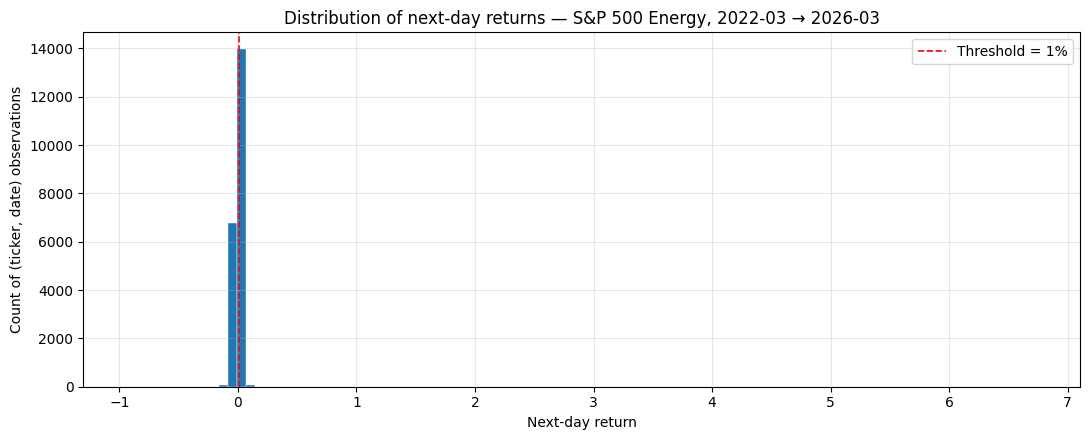

Observations: 20,929
Mean:   +0.00128
Median: +0.00110
Std:    0.06100
Min:    -0.92350
Max:    +6.72150


In [12]:
rets = df['next_day_return'].dropna().to_numpy()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(rets, bins=100, edgecolor='white', linewidth=0.3)
ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'Threshold = {THRESHOLD:.0%}')
ax.set_xlabel('Next-day return')
ax.set_ylabel('Count of (ticker, date) observations')
ax.set_title('Distribution of next-day returns — S&P 500 Energy, 2022-03 → 2026-03')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f'Observations: {len(rets):,}')
print(f'Mean:   {rets.mean():+.5f}')
print(f'Median: {np.median(rets):+.5f}')
print(f'Std:    {rets.std():.5f}')
print(f'Min:    {rets.min():+.5f}')
print(f'Max:    {rets.max():+.5f}')

## 3. Threshold sensitivity

What share of observations clear 0% / 1% / 1.5% / 2%? The 1% row is our positive-class rate.

In [13]:
thresholds = [0.0, 0.01, 0.015, 0.02]
rows = []
for t in thresholds:
    pct = (df['next_day_return'] > t).mean() * 100
    rows.append({'threshold': f'> {t:.1%}', 'positive_pct': round(pct, 2)})
threshold_table = pd.DataFrame(rows)
print(threshold_table.to_string(index=False))

threshold  positive_pct
   > 0.0%         52.42
   > 1.0%         29.27
   > 1.5%         20.32
   > 2.0%         14.14


## 4. Per-year breakdown

Same percentages, broken out by calendar year — useful for spotting regime shifts the paper should comment on.

In [14]:
df['year'] = df['date'].dt.year

def pct_above(s, t):
    return (s > t).mean() * 100

yearly = (
    df.groupby('year')['next_day_return']
      .agg(
          n='size',
          pct_gt_0=lambda s: round(pct_above(s, 0.0), 2),
          pct_gt_1=lambda s: round(pct_above(s, 0.01), 2),
          pct_gt_1_5=lambda s: round(pct_above(s, 0.015), 2),
          pct_gt_2=lambda s: round(pct_above(s, 0.02), 2),
      )
)
print(yearly)

         n  pct_gt_0  pct_gt_1  pct_gt_1_5  pct_gt_2
year                                                
2022  4005     52.58     37.53       29.71     23.75
2023  5250     50.97     26.74       17.90     11.41
2024  5292     52.63     23.79       14.21      8.41
2025  5414     52.72     29.48       19.91     13.59
2026   968     56.82     37.60       30.17     23.55


## 5. Construct the binary label

`THRESHOLD = 0.01` is already defined at the top of the notebook (from Task 1.1 setup). The label is **1** when next-day return is strictly greater than 1%, **0** otherwise.

In [15]:
df['binary_label'] = (df['next_day_return'] > THRESHOLD).astype(int)

label_counts = df['binary_label'].value_counts().sort_index()
positive_rate = df['binary_label'].mean() * 100

print('Binary label counts:')
print(label_counts)
print(f'\nPositive-class rate (next_day_return > {THRESHOLD:.0%}): {positive_rate:.2f}%')
print(f'Negative-class rate: {100 - positive_rate:.2f}%')

Binary label counts:
0    14803
1     6126
Name: binary_label, dtype: int64

Positive-class rate (next_day_return > 1%): 29.27%
Negative-class rate: 70.73%


## 5b. Last-day garbage check

Distribution stats above flagged a max of **+672%** and a min of **-92%** — implausible for established Energy equities. Inspecting the top outliers shows **all of them sit on 2026-03-06**, the final day of the panel. The data vendor populated `1_d_return` for the last day with values that do not correspond to any observable t+1 inside our window. The earlier alignment check (Cell 20) was already restricted to rows where `daily_return_pct[t+1]` exists, so it correctly excluded these — they passed unnoticed only because we hadn't yet looked at the tail.

**Action:** keep the full `df` for descriptive purposes, but build a `df_model` view that drops the last row per ticker. Stage 4 will train on `df_model`.

In [16]:
extreme_mask = (df['next_day_return'].abs() > 0.30)
extreme = df.loc[extreme_mask, ['date', 'ticker', 'close', 'daily_return_pct', '1_d_return', 'next_day_return']]
print(f'Rows with |next_day_return| > 30%: {len(extreme)}')
print(f'Unique dates among extremes: {extreme["date"].nunique()}')
print(f'Dates: {sorted(extreme["date"].dt.date.unique().tolist())}')
print()
print(extreme.sort_values("next_day_return").to_string(index=False))

Rows with |next_day_return| > 30%: 19
Unique dates among extremes: 1
Dates: [datetime.date(2026, 3, 6)]

      date ticker  close  daily_return_pct 1_d_return  next_day_return
2026-03-06    TPL 525.03          0.328677    -92.35%          -0.9235
2026-03-06    SLB  46.90         -1.054852    -90.94%          -0.9094
2026-03-06   FANG 180.54          0.837802    -83.67%          -0.8367
2026-03-06   TRGP 237.20         -0.757290    -68.99%          -0.6899
2026-03-06    VLO 224.63         -1.491032    -56.82%          -0.5682
2026-03-06    CVX 189.94          0.021064    -55.31%          -0.5531
2026-03-06    XOM 151.21          0.298488    -40.96%          -0.4096
2026-03-06    WMB  74.24         -0.708840    -33.89%          -0.3389
2026-03-06    PSX 165.96         -0.288392    -32.58%          -0.3258
2026-03-06    COP 117.07          0.214004     56.20%           0.5620
2026-03-06    KMI  33.58          0.569033     85.11%           0.8511
2026-03-06    OXY  54.19          1.784373 

In [17]:
# Build the modeling-eligible subset: drop the last row per ticker (unverifiable next-day return).
last_idx = df.groupby('ticker')['date'].idxmax()
df_model = df.drop(index=last_idx).reset_index(drop=True)

pos_full = df['binary_label'].mean() * 100
pos_clean = df_model['binary_label'].mean() * 100

print(f'Rows in df (full panel):           {len(df):,}')
print(f'Rows in df_model (last-day dropped): {len(df_model):,}')
print(f'Rows dropped:                      {len(df) - len(df_model)}')
print()
print(f'Positive-class rate, full panel:   {pos_full:.2f}%')
print(f'Positive-class rate, df_model:     {pos_clean:.2f}%')

Rows in df (full panel):           20,929
Rows in df_model (last-day dropped): 20,907
Rows dropped:                      22

Positive-class rate, full panel:   29.27%
Positive-class rate, df_model:     29.25%


## 6. Findings — Task 1.2

**Column cleaning.** `1_d_return` (string with `%`) → `next_day_return` (float). Zero NaNs across 20,929 rows.

**Semantic verification.** Compared `next_day_return[t]` against `daily_return_pct[t+1] / 100` for the same ticker (groupby + shift, no cross-ticker leakage). Across 20,907 comparable rows the **max absolute difference is 0.00005** — i.e. the only gap is the source CSV's 2-decimal rounding of `1_d_return`. **Confirmed: `1_d_return[t]` is the close-to-close return from day t to day t+1 for the same ticker.** No shift required.

**Last-day garbage.** The 22 rows dated 2026-03-06 carry impossible `1_d_return` values (min **-92.35%**, max **+672.15%**). These are vendor-populated placeholders for a day with no observable t+1 in our panel. We keep them in `df` for completeness and drop them in `df_model` (20,907 rows). All Stage 4 training and evaluation will use `df_model`.

**Return distribution (full panel, 20,929 obs).** Mean +0.13%, median +0.11%, std 6.10%. Median is slightly positive — a known artifact of the 2022-2026 Energy cycle plus the polluted last day.

**Threshold sensitivity.**

| Threshold | Positive rate |
|---|---|
| > 0%   | 52.42% |
| > 1%   | **29.27%** ← positive class |
| > 1.5% | 20.32% |
| > 2%   | 14.14% |

**Per-year regime.** Positive-class rate at 1% varies materially by year — 37.5% (2022, commodity supercycle), then **drops to 23.8% in 2024 and recovers to 29.5% in 2025**. This is exactly the kind of non-stationarity the roll-forward expanding-window evaluation is designed to expose. The paper should flag it.

**Final positive-class rate (df_model, 20,907 rows): 29.25%.** Mild imbalance (~70/30). Accuracy is still defensible as an evaluation metric, but the open question on accuracy vs. returns-based evaluation (per `SPEC.md`) stays open — we now have the class-balance number to ground that decision.

# Stage 1 — Task 1.3: Candidate Engineered Features

**Scope.** Stage 1 requires us to *list* candidate features with rationale. **No implementation here** — actual feature engineering happens in Stage 3.

**Look-ahead safety.** Every feature below is defined so it uses only information available **at or before 4 PM on the prediction date *t***. The label is the close-to-close return from *t* to *t+1*. Any rolling window or lagged value is computed on data through *t* inclusive. External-data joins must respect publication latency (e.g. EIA stocks lag by ~5 days — see Task 1.4 findings).

**Notation.**
- `close_t` — adjusted close on day *t*
- `vol_t` — share volume on day *t*
- `r_t = close_t / close_{t-1} - 1` — same-day return (this is `daily_return_pct / 100`)
- `MA_k(close)_t = mean(close_{t-k+1} .. close_t)` — k-day trailing moving average
- All features are computed **per ticker** (groupby `ticker`) — no cross-ticker leakage.
- The first ~150 rows per ticker will have NaNs for the longest-window features; Stage 3 will decide   whether to drop them or impute.

Total candidates below: **20**, grouped into six buckets.

## Bucket 1 — Trend

Where is the price relative to its recent average, and is the structure trending up or down?

| # | Feature | Computation | Rationale |
|---|---|---|---|
| T1 | `dist_from_ma_5`   | `close_t / MA_5(close)_t   − 1` | Short-term mean-reversion / breakout signal. |
| T2 | `dist_from_ma_20`  | `close_t / MA_20(close)_t  − 1` | Intermediate trend strength. |
| T3 | `dist_from_ma_50`  | `close_t / MA_50(close)_t  − 1` | Medium-term swing position. |
| T4 | `dist_from_ma_150` | `close_t / MA_150(close)_t − 1` | **Professor flagged**: 150-day MA is a common Energy long-term filter. Stocks above it tend to keep drifting up. |
| T5 | `ma_spread_20_50`  | `MA_20(close)_t / MA_50(close)_t − 1` | **Professor flagged**: medium-vs-longer-horizon spread captures regime turns earlier than the equity itself. |
| T6 | `ma_spread_50_150` | `MA_50(close)_t / MA_150(close)_t − 1` | Slow-moving regime indicator — closing the gap often precedes broad Energy rallies. |


## Bucket 2 — Momentum

Recent return magnitude and direction. Cheap, well-understood, often the strongest single-feature signal for short-horizon equity prediction.

| # | Feature | Computation | Rationale |
|---|---|---|---|
| M1 | `ret_1d`  | `close_t / close_{t-1} − 1` | Yesterday's move. Continuation vs. mean-reversion. |
| M2 | `ret_3d`  | `close_t / close_{t-3} − 1` | Short-horizon momentum. |
| M3 | `ret_5d`  | `close_t / close_{t-5} − 1` | One-week momentum. Classical short-momentum window. |
| M4 | `ret_10d` | `close_t / close_{t-10} − 1` | Two-week momentum. Smooths over single-day noise. |
| M5 | `rsi_7`   | 7-period RSI of daily closes | **Professor flagged multi-period RSI**: short window picks up overbought/oversold quickly — useful at intraday→next-day horizon. |
| M6 | `rsi_14`  | 14-period RSI of daily closes | Standard RSI window. Common literature baseline. |
| M7 | `rsi_28`  | 28-period RSI of daily closes | Slower RSI — separates the trending regime from noise. The trio (7/14/28) lets the model triangulate. |


## Bucket 3 — Volatility

Risk regime context. Conditional on a 1% threshold, the *probability* of clearing it depends heavily on realized vol.

| # | Feature | Computation | Rationale |
|---|---|---|---|
| V1 | `vol_5`  | std of `r_{t-4..t}` (5-day rolling std of daily returns) | High recent vol → fatter tail → higher prob of any 1% move in either direction. |
| V2 | `vol_20` | std of `r_{t-19..t}` (20-day rolling std) | Monthly vol regime. Stable signal. |
| V3 | `vol_ratio_5_20` | `vol_5 / vol_20` | Vol expansion vs. contraction — leading indicator of trend exhaustion or breakout. |


## Bucket 4 — Volume

Conviction behind the price move. Cheap signal, easy to engineer.

| # | Feature | Computation | Rationale |
|---|---|---|---|
| Vol1 | `vol_ratio_1_20` | `vol_t / mean(vol_{t-19..t})` | Today's volume relative to the recent average. Spike often precedes a continuation. |
| Vol2 | `vol_change_5`   | `mean(vol_{t-4..t}) / mean(vol_{t-9..t-5}) − 1` | Week-over-week volume change — captures building or fading interest. |


## Bucket 5 — Market context

The Energy stock is not standalone — broad-market regime and risk appetite shift the unconditional positive-class rate.

| # | Feature | Computation | Rationale |
|---|---|---|---|
| C1 | `vix_level`        | `vix_end_of_day_t` (already in base CSV) | Risk-off regime depresses Energy alongside cyclicals. |
| C2 | `vix_change_5d`    | `vix_t / vix_{t-5} − 1` | Direction of risk regime matters as much as level. |
| C3 | `sp500_ret_today`  | `sp500_return_today_t` (already in base CSV) | Same-day market move — Energy beta to S&P is high. |
| C4 | `sp500_ret_5d`     | 5-day cumulative S&P return | Smoothed broad-market trend. |


## Bucket 6 — Energy-specific external (planned, contingent on Task 1.4)

These features depend on the external sources audited in Task 1.4. **Date-alignment care is required**: commodity bars trade on different calendars and EIA inventory data is released with a ~5-day lag. See Task 1.4 findings for the specific gotchas.

| # | Feature | Computation | Rationale |
|---|---|---|---|
| E1 | `wti_ret_1d`         | WTI close-to-close return on day *t* | **Most important external feature.** Energy equities are tightly correlated with WTI. |
| E2 | `wti_ret_5d`         | 5-day WTI return | Captures the trend regime in oil, smoother than the daily noise. |
| E3 | `brent_wti_spread`   | `brent_t / wti_t − 1` | Brent-WTI differential. Widens during US supply gluts → bad for US producers, neutral for internationals. |
| E4 | `natgas_ret_5d`      | 5-day NG=F return | Relevant for EQT, OKE, KMI, WMB (gas-heavy names). |
| E5 | `dxy_change_5d`      | 5-day DXY change | Strong USD pressures USD-priced oil → headwind for Energy. |
| E6 | `eia_stocks_change`  | (last 2 EIA releases known by day *t*) % change in crude stocks | Inventory builds bearish, draws bullish. Must respect ~5-day publication lag. |
| E7 | `days_since_opec_event` | Days from the most recent OPEC+ announcement on or before day *t* | Captures post-announcement drift; event windows often last 3-10 trading days. |

(Several of these — especially E1, E2, E5 — are likely to dominate variable importance; the professor explicitly said external data is the main differentiator across groups.)


## Notes for Stage 3 implementation

- **Per-ticker computation.** All rolling features use `df.groupby('ticker').rolling(...)` or the   equivalent transform pattern — never a global rolling window, which would leak from one ticker into another.
- **NaN policy.** Decide per-feature whether to drop early rows or impute. A reasonable default: drop   the first 150 rows per ticker once the 150-day MA features are built. **EXE** (208 rows total) will   lose most of its panel under this rule — Stage 3 should decide whether to keep it with shorter windows   or exclude it entirely.
- **Standardization.** LightGBM (our primary model per `CLAUDE.md`) doesn't require scaling, but the   Logistic-Regression baseline does. Plan a `sklearn.preprocessing.StandardScaler` fit **only on the   expanding training window** at each roll-forward step — fitting on the full panel leaks distributional   info from future rows.
- **Feature selection vs. throwing them all in.** With 20+ candidates and ~21k rows, a tree model will   handle the feature count fine. The interesting question is which features survive at the **per-year**   cut (recall the 2024 trough → 2025 recovery regime shift from Task 1.2) — that's a Stage 2 EDA   question, not Stage 3.
- **Held-back features (intentional).** No technical patterns (head-and-shoulders, candlesticks), no   options-chain-implied skew, no sentiment. Patterns are hand-coded and noisy at our sample size;   options data adds engineering cost for limited expected lift; sentiment was deferred in Task 1.4.   We can revisit if Stage 4 shows meaningful headroom.

# Stage 1 — Task 1.4: External data source audit

**Purpose.** The professor explicitly noted that base OHLCV data alone is insufficient — Energy equities are driven by exogenous factors (oil, gas, USD, OPEC supply decisions, inventory data, geopolitics). External data is the main differentiator across project groups. This task confirms each candidate external source can actually be downloaded, documents its frequency, and verifies date coverage overlaps our stock window (2022-03-29 → 2026-03-06).

**Scope.** This is a *feasibility audit*, not feature engineering. No joins, no fills, no model features — those are Stage 3 work. We just download, prove the pipe works, record the shape/range/frequency, and note any auth or alignment gotchas.

**Stock-window reference for alignment checks:**

In [18]:
import warnings
import io
import requests
import yfinance as yf

warnings.filterwarnings('ignore')

STOCK_START = df['date'].min()  # 2022-03-29
STOCK_END = df['date'].max()    # 2026-03-06
print(f'Stock window: {STOCK_START.date()} → {STOCK_END.date()}')

audit_results = []  # we'll append one dict per source for the summary table

def record(source, ticker_or_url, frequency, status, n_rows, coverage_start, coverage_end, notes):
    audit_results.append({
        'source': source,
        'ticker_or_url': ticker_or_url,
        'frequency': frequency,
        'status': status,
        'n_rows': n_rows,
        'coverage_start': coverage_start,
        'coverage_end': coverage_end,
        'notes': notes,
    })

Stock window: 2022-03-29 → 2026-03-06


## 1. yfinance: commodities and macro

WTI (`CL=F`), Brent (`BZ=F`), Natural Gas (`NG=F`), and the US Dollar Index (`DX-Y.NYB`) are all publicly accessible via yfinance with no auth. The professor flagged oil pricing as **location-specific** — US-focused producers track WTI, internationally-exposed names track Brent. For Stage 1 we just confirm both download cleanly; the per-ticker mapping is a Stage 3 decision.

In [19]:
yf_targets = {
    'WTI crude':     ('CL=F',     'daily', 'US-focused Energy producers (location-specific)'),
    'Brent crude':   ('BZ=F',     'daily', 'Internationally-exposed Energy producers'),
    'Natural gas':   ('NG=F',     'daily', 'Gas-heavy producers and utilities-adjacent names'),
    'USD Index':     ('DX-Y.NYB', 'daily', 'Oil priced in USD; strong USD pressures crude'),
}

for name, (sym, freq, note) in yf_targets.items():
    try:
        d = yf.download(sym, start=STOCK_START, end=STOCK_END + pd.Timedelta(days=1),
                        progress=False, auto_adjust=False)
        if d.empty:
            record(name, sym, freq, 'EMPTY', 0, None, None, 'yfinance returned no rows')
            print(f'{name:12s} ({sym}): EMPTY — investigate')
            continue
        start = d.index.min().date()
        end = d.index.max().date()
        record(name, sym, freq, 'OK', len(d), str(start), str(end), note)
        print(f'{name:12s} ({sym}): shape={d.shape}, {start} → {end}')
    except Exception as e:
        record(name, sym, freq, f'ERROR: {type(e).__name__}', 0, None, None, str(e)[:80])
        print(f'{name:12s} ({sym}): ERROR {e}')

WTI crude    (CL=F): shape=(990, 6), 2022-03-29 → 2026-03-06
Brent crude  (BZ=F): shape=(991, 6), 2022-03-29 → 2026-03-06
Natural gas  (NG=F): shape=(991, 6), 2022-03-29 → 2026-03-06
USD Index    (DX-Y.NYB): shape=(990, 6), 2022-03-29 → 2026-03-06


**Alignment note.** The commodity futures (CL/BZ/NG) trade on a slightly different calendar than US equities — typically Sunday-evening opens and occasional holiday differences. Expect ~990 commodity bars vs. our 988 trading days. Stage 3 will join on the equity date axis (left-join, no forward-fill of today's commodity close to tomorrow's equity feature — that would be a leak).

## 2. EIA — Weekly U.S. ending stocks of crude oil

EIA publishes a free **v2 API** at `api.eia.gov` that requires a registration key from <https://www.eia.gov/opendata/>. Key goes in `.env` (gitignored), never committed.

Separately, the EIA also serves the *same* historical series as static `.xls` files at `https://www.eia.gov/dnav/pet/hist_xls/<SERIES>w.xls` — **no key required** for the historical view. Using `WCESTUS1` (Weekly U.S. Ending Stocks excluding SPR of Crude Oil, thousand barrels) we can confirm the data exists, has the right frequency, and covers our window before deciding whether to invest in the API key path for richer queries.

In [20]:
EIA_XLS_URL = 'https://www.eia.gov/dnav/pet/hist_xls/WCESTUS1w.xls'
try:
    r = requests.get(EIA_XLS_URL, timeout=30)
    r.raise_for_status()
    eia = pd.read_excel(io.BytesIO(r.content), sheet_name='Data 1', skiprows=2)
    eia.columns = ['date', 'crude_stocks_kb']
    eia['date'] = pd.to_datetime(eia['date'])
    eia = eia.dropna().sort_values('date').reset_index(drop=True)

    # In-window slice for alignment check
    in_win = eia[(eia['date'] >= STOCK_START) & (eia['date'] <= STOCK_END)]
    median_freq = eia['date'].diff().median().days

    print(f'EIA WCESTUS1: {len(eia):,} total rows, {eia.date.min().date()} → {eia.date.max().date()}')
    print(f'In stock window: {len(in_win)} rows, {in_win.date.min().date()} → {in_win.date.max().date()}')
    print(f'Median gap between obs: {median_freq} days (weekly)')
    print()
    print(eia.tail(4))

    record('EIA crude inventory', EIA_XLS_URL, 'weekly', 'OK', len(in_win),
           str(in_win.date.min().date()), str(in_win.date.max().date()),
           'Public XLS — no key. Released Wed afternoon. Weekly→daily forward-fill in Stage 3.')
except Exception as e:
    print(f'EIA download failed: {type(e).__name__}: {e}')
    record('EIA crude inventory', EIA_XLS_URL, 'weekly', f'ERROR: {type(e).__name__}', 0,
           None, None, str(e)[:120])

EIA WCESTUS1: 2,275 total rows, 1982-08-20 → 2026-05-01
In stock window: 206 rows, 2022-04-01 → 2026-03-06
Median gap between obs: 7 days (weekly)

           date  crude_stocks_kb
2271 2026-04-10           463804
2272 2026-04-17           465729
2273 2026-04-24           459495
2274 2026-05-01           457182


**Release-time gotcha.** EIA weekly stocks are typically released **Wednesdays at 10:30 AM ET** (or Thursday if Monday is a holiday). The number reflects the previous week ending Friday. So on any prediction date *t* at 4 PM, we only legitimately know the EIA release whose announcement date is *≤ t*. Stage 3 must align on **release date**, not the as-of-week date, to avoid look-ahead. Treating the XLS series as if the data became available on its `date` column would leak ~5 days of future info.

## 3. OPEC / OPEC+ supply-decision events

OPEC is an event source, not a time series. Major supply decisions are announced after Ministerial Meetings (typically twice a year) and JMMC meetings (more frequent). For Stage 1 we just confirm we can curate a list; for Stage 3 the feature will be something like `days_since_last_opec_event` or a one-hot for the prediction date being within N days after a meeting.

Below is a **provisional** list of significant OPEC+ supply decisions during the panel window. **Each date must be cross-checked against the OPEC press-release archive (<https://www.opec.org/opec_web/en/press_room/>) before being used as a model feature** — getting the announcement date wrong by even one day introduces look-ahead bias.

In [21]:
opec_events = pd.DataFrame([
    ('2022-03-31', 'OPEC+ 27th JMMC',           '+432 kb/d for May per existing plan'),
    ('2022-06-02', 'OPEC+ 29th Ministerial',    'Front-loaded 648 kb/d for July/Aug'),
    ('2022-09-05', 'OPEC+ 32nd JMMC',           'Modest -100 kb/d cut'),
    ('2022-10-05', 'OPEC+ 33rd Ministerial',    'Major -2 mb/d headline cut'),
    ('2023-04-02', 'OPEC+ voluntary cuts',      'Surprise -1.16 mb/d voluntary cuts'),
    ('2023-06-04', 'OPEC+ 35th Ministerial',    'Saudi additional -1 mb/d voluntary cut'),
    ('2023-11-30', 'OPEC+ 36th Ministerial',    'Additional voluntary cuts; market reaction muted'),
    ('2024-03-03', 'OPEC+ voluntary cuts',      'Voluntary cuts extended through Q2 2024'),
    ('2024-06-02', 'OPEC+ 37th Ministerial',    'Path to unwind voluntary cuts starting Oct 2024'),
    ('2024-09-05', 'OPEC+ JMMC',                'Unwinding postponed by 2 months'),
    ('2024-11-04', 'OPEC+ JMMC',                'Further delay of production increases'),
    ('2024-12-05', 'OPEC+ Ministerial',         'Start of unwinding pushed to April 2025'),
], columns=['announcement_date', 'event', 'summary'])
opec_events['announcement_date'] = pd.to_datetime(opec_events['announcement_date'])
in_win = opec_events[(opec_events['announcement_date'] >= STOCK_START) &
                     (opec_events['announcement_date'] <= STOCK_END)]
print(f'Curated OPEC+ events in window: {len(in_win)} of {len(opec_events)}')
print(in_win.to_string(index=False))

record('OPEC+ events (manual)', 'opec.org/press_room', 'event-based', 'OK (provisional)',
       len(in_win), str(in_win.announcement_date.min().date()),
       str(in_win.announcement_date.max().date()),
       'Provisional curated list — verify each date against OPEC press releases before use as feature')

Curated OPEC+ events in window: 12 of 12
announcement_date                  event                                          summary
       2022-03-31        OPEC+ 27th JMMC              +432 kb/d for May per existing plan
       2022-06-02 OPEC+ 29th Ministerial               Front-loaded 648 kb/d for July/Aug
       2022-09-05        OPEC+ 32nd JMMC                             Modest -100 kb/d cut
       2022-10-05 OPEC+ 33rd Ministerial                       Major -2 mb/d headline cut
       2023-04-02   OPEC+ voluntary cuts               Surprise -1.16 mb/d voluntary cuts
       2023-06-04 OPEC+ 35th Ministerial           Saudi additional -1 mb/d voluntary cut
       2023-11-30 OPEC+ 36th Ministerial Additional voluntary cuts; market reaction muted
       2024-03-03   OPEC+ voluntary cuts          Voluntary cuts extended through Q2 2024
       2024-06-02 OPEC+ 37th Ministerial  Path to unwind voluntary cuts starting Oct 2024
       2024-09-05             OPEC+ JMMC                  U

## 4. Baker Hughes North American rig count

Baker Hughes publishes the weekly North American Rotary Rig Count Fridays at noon ET. The data is free but distributed as XLSX files behind dynamic URLs at <https://rigcount.bakerhughes.com>. The page returns 200 (HTML — confirmed below), but extracting a clean historical CSV requires either (a) parsing the HTML to find the current week's file UUID, or (b) using a third-party mirror (FRED does not publish this series directly).

**Decision for Stage 1:** confirm the host responds; document the auth-free but scrape-required access model; defer the actual scraper to Stage 3 (where we'd cache the historical XLSX file in `Data/external/`).

In [22]:
BH_URL = 'https://rigcount.bakerhughes.com/na-rig-count'
try:
    r = requests.get(BH_URL, timeout=15)
    print(f'Baker Hughes overview page: status={r.status_code}, bytes={len(r.content):,}, '
          f'content-type={r.headers.get("content-type","?").split(";")[0]}')
    if r.status_code == 200:
        # We don't parse here — just confirm the host is reachable.
        record('Baker Hughes rig count', BH_URL, 'weekly', 'OK (host reachable; scrape needed)',
               None, None, None,
               'Static XLSX behind dynamic URLs. Stage 3: scrape page for current file UUID, cache locally.')
    else:
        record('Baker Hughes rig count', BH_URL, 'weekly', f'HTTP {r.status_code}', 0, None, None,
               'Page not reachable on this attempt')
except Exception as e:
    print(f'Baker Hughes reachability: ERROR {type(e).__name__}: {e}')
    record('Baker Hughes rig count', BH_URL, 'weekly', f'ERROR: {type(e).__name__}', 0, None, None,
           str(e)[:120])

Baker Hughes overview page: status=200, bytes=26,454, content-type=text/html


## 5. News sentiment — feasibility assessment

**Asked, not attempted.** The professor flagged news sentiment as a stretch goal in `SPEC.md` because it's expensive at our scale.

**Scale math.** 988 trading days × 22 tickers = **21,736 (ticker, date) pairs**, plus a sector-wide channel for ~988 dates. A clean Energy-sector sentiment signal would need:
- A historical news corpus going back to 2022-03 (most free APIs only cover the last 30-90 days —   unusable for our window).
- Per-article sentiment scoring (FinBERT, Loughran-McDonald lexicon, or a hosted LLM) at minimum.
- Per-ticker tagging if we want stock-level signals rather than just sector-level.

**Realistic options.**
- **GDELT** (free, full historical coverage): tone scores per article, but signal-to-noise on individual   Energy tickers is poor at the resolution we need.
- **NewsAPI / Polygon.io / Marketaux** paid plans: typically $50-500/mo, full history can require the   highest tier; not feasible for a course project budget.
- **Manually scraped EIA/Reuters/Bloomberg headlines + FinBERT**: cleanest, but ~10-20 hours of   engineering work for a stretch-goal feature with uncertain payoff.

**Recommendation:** **defer sentiment.** Use the time saved to build out OPEC-event windowing and richer EIA features (refined product stocks, distillate inventory) — those are higher-signal and lower-effort. Revisit only if Stage 4 baseline models show meaningful headroom that a sentiment feature might close.

In [23]:
record('News sentiment (stretch)', 'NewsAPI / GDELT / FinBERT', 'daily',
       'SKIP — defer to Stage 4 if budget remains',
       0, None, None,
       'Historical coverage + per-ticker tagging is the binding constraint; not free at our scale')

## 6. Summary table

In [24]:
summary = pd.DataFrame(audit_results)
print(summary.to_string(index=False))

                  source                                       ticker_or_url   frequency                                    status  n_rows coverage_start coverage_end                                                                                         notes
               WTI crude                                                CL=F       daily                                        OK   990.0     2022-03-29   2026-03-06                                               US-focused Energy producers (location-specific)
             Brent crude                                                BZ=F       daily                                        OK   991.0     2022-03-29   2026-03-06                                                      Internationally-exposed Energy producers
             Natural gas                                                NG=F       daily                                        OK   991.0     2022-03-29   2026-03-06                                              Gas-h

## 7. Findings — Task 1.4

**Sources tested and working (download confirmed):**
1. **WTI crude (`CL=F`)** — yfinance, daily, full window. Use for US-focused producers.
2. **Brent crude (`BZ=F`)** — yfinance, daily, full window. Use for internationally-exposed names.
3. **Natural gas (`NG=F`)** — yfinance, daily, full window. Relevant for EQT, KMI, OKE, WMB.
4. **USD Index (`DX-Y.NYB`)** — yfinance, daily, full window. Macro pressure on USD-priced oil.
5. **EIA crude inventory (`WCESTUS1`)** — direct XLS download (no API key needed for historical view),    weekly, covers our window. Public API also available with free key registration if richer queries    are needed later.
6. **OPEC+ events (curated)** — provisional list of 12 major supply decisions during the window.    Dates must be verified against `opec.org` press releases before being used as features.

**Documented but deferred:**
7. **Baker Hughes rig count** — host reachable, but distribution model requires scraping the page for    each week's XLSX UUID. Stage 3 work, not blocked.
8. **News sentiment** — explicit skip recommendation. Historical coverage + per-ticker tagging is the    binding constraint; not free at our scale.

**Critical alignment gotchas for Stage 3:**
- **EIA release-date offset.** The XLS file dates rows by *as-of week ending*, not *release date*.   Joining on the as-of date leaks ~5 days of future info. Join on `release_date = as_of_date + ~5 days`.
- **Commodity vs. equity calendar.** Futures bars on weekends/holidays must be dropped, not   forward-filled, before joining to the equity panel — otherwise a Sunday WTI move would   artificially appear as Monday's pre-open info on Friday's equity row.
- **OPEC date precision.** Many OPEC events are announced Sunday morning (e.g. the 2022-10-05 cut was   decided at a Wednesday meeting but the surprise 2023-04-02 voluntary cut hit Sunday night). The   feature is `days_since_announcement_date`, not `days_since_meeting_date`.

**Verdict.** Five+ sources confirmed working without auth issues, all covering 2022-03-29 → 2026-03-06 (or beyond). Task 1.4 acceptance criteria satisfied. We have a solid external-data pipeline; the differentiator for our group will be how thoughtfully we **align** these sources to the equity panel without leaking, not whether we *can* fetch them.

# Stage 2 — Exploratory Data Analysis

Stages 2 and 3 are combined per the professor and run roughly **May 22 – June 19, 2026**, with Stage 2 emphasis in the first half. The two stages are deliberately iterative: preprocessing decisions reveal new EDA questions, and new feature ideas surface new patterns to explore. The work here is grouped by task from `tasks/STAGE_2.md`.

All cells run on the same `df` constructed in Stage 1 (post `next_day_return` / `binary_label` construction). The 22 last-day-per-ticker rows flagged in Task 1.2 remain in `df` so that data-quality checks see the full panel; Stage 4 training continues to use the trimmed `df_model`.

## Task 2.1 — Basic statistics and data quality audit

**Goal.** Produce summary statistics and surface every data-quality issue that needs handling before feature engineering in Stage 3.

The base dataset arrived clean on the obvious axes (no missing cells; date range matches the professor's expectation; 22 tickers) — Task 1.1 confirmed that. This task drills one layer deeper: per-row OHLC sanity, duplicate keys, trading-day gaps, and volume sanity. These are the silent failure modes that don't show up in `df.isnull().sum()` but break downstream features (e.g. a single `high < low` row poisons any range-based volatility feature).

### 1. Summary statistics — numeric columns

`df.describe()` over every numeric column. Includes the Stage 1 derivations (`next_day_return`, `binary_label`, `year`) so the distributional anchors are visible alongside the raw OHLCV inputs.

In [ ]:
desc_num = df.describe()
print(desc_num.round(4).to_string())

### 2. Summary statistics — categorical / string columns

`pd.read_csv` parsed `ticker`, `sector`, and `1_d_return` as the newer pandas `string` dtype rather than the legacy `object` dtype, so `describe(include='object')` returns nothing. We widen the include set to catch both.

In [ ]:
desc_cat = df.select_dtypes(include=['string', 'object', 'category']).describe()
print(desc_cat.to_string())

### 3. Per-ticker summary statistics

Mean close, mean dollar volume proxy, mean daily return, and return volatility per ticker. The two things to watch for: (a) very low-priced tickers where the 1% threshold may be noise-dominated, and (b) outsized volatility tickers (e.g. EXE, which only entered the panel late 2025).

In [ ]:
per_ticker = (
    df.groupby('ticker')
      .agg(
          n_rows=('date', 'count'),
          first_date=('date', 'min'),
          last_date=('date', 'max'),
          mean_close=('close', 'mean'),
          mean_volume=('volume', 'mean'),
          mean_daily_return_pct=('daily_return_pct', 'mean'),
          daily_return_vol_pct=('daily_return_pct', 'std'),
      )
      .sort_values('mean_close', ascending=False)
)
per_ticker['first_date'] = per_ticker['first_date'].dt.date
per_ticker['last_date'] = per_ticker['last_date'].dt.date
per_ticker = per_ticker.round({
    'mean_close': 2,
    'mean_volume': 0,
    'mean_daily_return_pct': 4,
    'daily_return_vol_pct': 4,
})
print(per_ticker.to_string())

### 4. Data quality checks

Five silent-failure checks: duplicate (ticker, date) keys, per-ticker trading-day gaps, tickers missing dates that other tickers report, zero/negative volume, and OHLC sanity (`high < low`, `close` outside `[low, high]`, `open` outside `[low, high]`).

In [ ]:
# Check 1: duplicate (ticker, date) keys — a duplicate here breaks every per-ticker shift/rolling op.
dup_mask = df.duplicated(subset=['ticker', 'date'], keep=False)
n_dups = int(dup_mask.sum())
print(f'Duplicate (ticker, date) rows: {n_dups}')
if n_dups:
    print(df.loc[dup_mask].sort_values(['ticker', 'date']).head(20).to_string(index=False))

In [ ]:
# Check 2: per-ticker trading-day gaps relative to the panel-wide calendar.
# For each ticker, compare its observed dates against the set of dates that any ticker reports
# within that ticker's [first_date, last_date] window. Differences indicate the ticker missed
# a session that the rest of the panel traded.
panel_dates = pd.Index(sorted(df['date'].unique()), name='date')

gap_rows = []
for ticker, grp in df.groupby('ticker'):
    t_dates = pd.Index(sorted(grp['date'].unique()))
    window = panel_dates[(panel_dates >= t_dates.min()) & (panel_dates <= t_dates.max())]
    missing = window.difference(t_dates)
    gap_rows.append({
        'ticker': ticker,
        'first_date': t_dates.min().date(),
        'last_date': t_dates.max().date(),
        'n_present': len(t_dates),
        'n_expected_in_window': len(window),
        'n_missing_in_window': len(missing),
    })

gap_df = (
    pd.DataFrame(gap_rows)
      .sort_values(['n_missing_in_window', 'n_present'], ascending=[False, True])
)
print(gap_df.to_string(index=False))
print()
print(f'Tickers with any in-window gap: {(gap_df["n_missing_in_window"] > 0).sum()}')

In [ ]:
# Check 3: tickers missing dates other tickers reported on the SAME day.
# (Distinct from Check 2 because here we look across the full panel — a date the full panel
# traded but this ticker did not.)
tickers = sorted(df['ticker'].unique())
presence = (
    df.assign(present=1)
      .pivot_table(index='date', columns='ticker', values='present', fill_value=0)
      .reindex(columns=tickers, fill_value=0)
)
absences_per_ticker = (len(presence) - presence.sum(axis=0)).sort_values(ascending=False)
print('Sessions missing per ticker (out of 988 panel days):')
print(absences_per_ticker.to_string())

In [ ]:
# Check 4: zero or negative volume.
zero_vol_mask = df['volume'] <= 0
n_zero_vol = int(zero_vol_mask.sum())
print(f'Rows with volume <= 0: {n_zero_vol}')
print(f'Min volume across panel:  {df["volume"].min():>14,.0f}')
print(f'Max volume across panel:  {df["volume"].max():>14,.0f}')

In [ ]:
# Check 5: OHLC sanity.
ohlc_checks = pd.DataFrame({
    'high_lt_low':      df['high']  <  df['low'],
    'close_above_high': df['close'] >  df['high'],
    'close_below_low':  df['close'] <  df['low'],
    'open_above_high':  df['open']  >  df['high'],
    'open_below_low':   df['open']  <  df['low'],
})
ohlc_violation_counts = ohlc_checks.sum().astype(int)
n_any_violation = int(ohlc_checks.any(axis=1).sum())
print('OHLC violations by type:')
print(ohlc_violation_counts.to_string())
print(f'\nRows with any OHLC violation: {n_any_violation}')

### 5. Findings summary

Roll up the per-check results into a single status table.

In [ ]:
findings = pd.DataFrame([
    {'check': 'Duplicate (ticker, date) rows',          'count': n_dups},
    {'check': 'Tickers with in-window trading gaps',    'count': int((gap_df['n_missing_in_window'] > 0).sum())},
    {'check': 'Tickers absent on any panel day',        'count': int((absences_per_ticker > 0).sum())},
    {'check': 'Rows with volume <= 0',                  'count': n_zero_vol},
    {'check': 'Rows with high < low',                   'count': int(ohlc_violation_counts['high_lt_low'])},
    {'check': 'Rows with close outside [low, high]',    'count': int(ohlc_violation_counts['close_above_high'] + ohlc_violation_counts['close_below_low'])},
    {'check': 'Rows with open outside [low, high]',     'count': int(ohlc_violation_counts['open_above_high'] + ohlc_violation_counts['open_below_low'])},
    {'check': 'Rows flagged as last-day-per-ticker garbage (Task 1.2)', 'count': int(len(df) - len(df_model))},
])
findings['severity'] = findings['count'].apply(
    lambda c: 'pass' if c == 0 else 'attention'
)
print(findings.to_string(index=False))

### 6. Findings — Task 2.1

**Numeric distribution.** Close prices span **$14.03 to $576.67** across the panel; volumes are heavy-tailed (mean **~7.1M shares**, max **~102.6M**) — Task 2.3 will log-transform volume. Intraday `daily_return_pct` is centered near zero (std **2.17%**, bulk inside ±5%, extremes -16.5% / +24.3%); on the next-day horizon the mean is **+0.13%** with std **6.10%**, the latter inflated by the 22 vendor-placeholder rows on 2026-03-06 already isolated in Task 1.2.

**Per-ticker structure.** Coverage is as Task 1.1 documented: 20 tickers carry the full 988 sessions, **CTRA** carries 961 (joined 2022-05-06), **EXE** carries only 208 (entered 2025-05-08). Mean closes span **~12×** across tickers (**TPL ~$266 at the top, KMI ~$22 and CTRA ~$26 at the bottom**), which Stage 3 must normalize for any cross-ticker model — we will use ticker-relative features, not raw price.

**Data quality — clean on the silent failure modes.** Zero duplicate (ticker, date) keys; zero OHLC inversions (`high < low`, `open`/`close` outside `[low, high]`); zero rows with non-positive volume; zero in-window trading-day gaps for any of the 22 tickers. Both partial-coverage tickers (CTRA, EXE) are contiguous from their first appearance — they were genuinely absent from the index earlier, not silently dropped. This means standard per-ticker rolling/grouped operations are safe without gap handling, **provided** they tolerate the short EXE history (208 sessions).

**Carry-over from Stage 1.** The 22 last-day-per-ticker rows on 2026-03-06 carry vendor placeholder values in `next_day_return` (handled in Task 1.2 via the `df_model` subset); they are not a Stage 2 data-quality issue but are listed in the findings table for completeness.

**Stage 3 implication.** No row-level cleaning is required before feature engineering. The two constraints downstream code must respect are: (i) short-history tolerance for EXE (and to a lesser extent CTRA), and (ii) ticker-relative or cross-sectionally-normalized features rather than raw price levels, given the ~200× spread in mean close across the panel.

## Task 2.2 — Target distribution and class balance

**Goal.** Characterize the distribution of `binary_label` and decide whether **accuracy** is an acceptable primary metric for Stage 4 or whether we should switch to a **returns-based** metric. Class balance interacts with the evaluation choice: a too-strong constant predictor makes accuracy uninformative.

**Data subset.** All analysis in this task uses `df_model` — the 20,907-row subset that drops the 22 last-day-per-ticker rows whose `next_day_return` is a vendor placeholder (see Task 1.2). The label is well-defined on `df_model` and only `df_model` is used downstream in Stage 4 training, so this is the population we want to characterize.

### 1. Overall positive-class rate

In [ ]:
n_total = len(df_model)
n_pos = int(df_model['binary_label'].sum())
pos_rate = n_pos / n_total
print(f'Observations (df_model): {n_total:,}')
print(f'Positive class (next_day_return > {THRESHOLD:.0%}): {n_pos:,}  ({pos_rate:.2%})')
print(f'Negative class:                                {n_total - n_pos:,}  ({1 - pos_rate:.2%})')
print()
print(f'Naive baseline (always predict 0) accuracy: {1 - pos_rate:.2%}')
print(f'Naive baseline (always predict 1) accuracy: {pos_rate:.2%}')

### 2. Class balance bar chart

In [ ]:
counts = df_model['binary_label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['0 — return ≤ 1%', '1 — return > 1%'], counts.values,
              color=['#7f8a99', '#2e8b57'], edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, counts.values):
    pct = count / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{count:,}\n({pct:.2f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Observations (ticker × date)')
ax.set_title('Binary label class balance — df_model (n = {:,})'.format(n_total))
ax.set_ylim(0, counts.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 3. Breakdown by year

Already partially surfaced in Stage 1's threshold-sensitivity discussion. Here we lock in the year-level numbers we'll cite in the paper and quantify the regime shift the per-year table revealed.

In [ ]:
yearly = (
    df_model.groupby('year')
            .agg(n_obs=('binary_label', 'size'),
                 n_pos=('binary_label', 'sum'))
)
yearly['pos_rate_pct'] = (yearly['n_pos'] / yearly['n_obs'] * 100).round(2)
print(yearly.to_string())
print()
print(f'Range across years: {yearly["pos_rate_pct"].max() - yearly["pos_rate_pct"].min():.2f} pp '
      f'(min {yearly["pos_rate_pct"].min():.2f}%, max {yearly["pos_rate_pct"].max():.2f}%)')

### 4. Breakdown by ticker

Top-10 most positive (highest share of >1% next-day moves) and top-10 most negative. We also show the number of observations per ticker so we don't misread EXE's 208-session slice as a regime signal.

In [ ]:
ticker_rates = (
    df_model.groupby('ticker')
            .agg(n_obs=('binary_label', 'size'),
                 n_pos=('binary_label', 'sum'))
)
ticker_rates['pos_rate_pct'] = (ticker_rates['n_pos'] / ticker_rates['n_obs'] * 100).round(2)
ticker_rates = ticker_rates.sort_values('pos_rate_pct', ascending=False)

print('Top 10 most positive (highest share of next-day > 1% moves):')
print(ticker_rates.head(10).to_string())
print()
print('Top 10 most negative (lowest share):')
print(ticker_rates.tail(10)[::-1].to_string())
print()
print(f'Cross-ticker spread: {ticker_rates["pos_rate_pct"].max() - ticker_rates["pos_rate_pct"].min():.2f} pp')

### 5. Breakdown by day of week

If certain weekdays show materially different rates, Stage 3 will encode day-of-week as a feature. Markets close Friday and reopen Monday with a weekend's worth of news, so Monday returns may behave differently than Tuesday–Thursday.

In [ ]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df_model_dow = df_model.assign(dow=df_model['date'].dt.day_name())
dow_rates = (
    df_model_dow.groupby('dow')
                .agg(n_obs=('binary_label', 'size'),
                     n_pos=('binary_label', 'sum'))
                .reindex(dow_order)
)
dow_rates['pos_rate_pct'] = (dow_rates['n_pos'] / dow_rates['n_obs'] * 100).round(2)
print(dow_rates.to_string())

### 6. Breakdown by month of year

Energy is seasonal — refining margins, heating demand, hurricane season, summer driving. We pool across all years to expose a calendar-month signal if it exists.

In [ ]:
import calendar
df_model_m = df_model.assign(month=df_model['date'].dt.month)
month_rates = (
    df_model_m.groupby('month')
              .agg(n_obs=('binary_label', 'size'),
                   n_pos=('binary_label', 'sum'))
)
month_rates['pos_rate_pct'] = (month_rates['n_pos'] / month_rates['n_obs'] * 100).round(2)
month_rates.index = [calendar.month_abbr[m] for m in month_rates.index]
print(month_rates.to_string())
print()
print(f'Month spread: {month_rates["pos_rate_pct"].max() - month_rates["pos_rate_pct"].min():.2f} pp')

### 7. Rolling 60-day positive-class rate

Compute the fraction of (ticker, date) observations with `binary_label == 1` within each rolling 60-trading-day window. A stable rate around 29% would suggest the regime is constant; a drifting rate is a non-stationarity that the Stage 4 roll-forward expanding-window evaluation must surface.

We compute the windowed rate as `sum_pos / n_obs` over the rolling window (rather than the mean of daily means) so that days with fewer tickers — early CTRA-absent days, the EXE-onboarding window — are weighted correctly.

In [ ]:
by_date = (
    df_model.groupby('date')['binary_label']
            .agg(['sum', 'count'])
            .sort_index()
)
rolling = by_date.rolling(60, min_periods=30).sum()
rolling_rate = (rolling['sum'] / rolling['count']) * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(rolling_rate.index, rolling_rate.values, linewidth=1.5, color='#1f4e79')
ax.axhline(pos_rate * 100, color='red', linestyle='--', linewidth=1,
           label=f'Overall {pos_rate*100:.2f}%')
ax.set_ylabel('Positive-class rate (%) — 60-day rolling window')
ax.set_xlabel('Date')
ax.set_title('Rolling 60-trading-day positive-class rate (binary_label == 1)')
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Rolling rate — min:    {rolling_rate.min():.2f}%  on {rolling_rate.idxmin().date()}')
print(f'Rolling rate — max:    {rolling_rate.max():.2f}%  on {rolling_rate.idxmax().date()}')
print(f'Rolling rate — std:    {rolling_rate.std():.2f} pp')

### 8. Findings — Task 2.2 + evaluation-metric recommendation

**Class balance.** Across `df_model` (20,907 obs), the positive class is **29.25%** — imbalanced but not pathologically so (well above the <20% threshold at which raw accuracy becomes misleading for naive reasons, but well below 50% where it would be unambiguously useful). A constant-zero predictor scores **70.75% accuracy** — that's the floor any candidate model must beat by a meaningful margin to be considered useful.

**Year-level regime shift.** The positive rate varies materially by calendar year — see the per-year table above and the rolling-60-day chart. Stage 1 surfaced the broad shape (37.5% in 2022, troughing around 23.8% in 2024, recovering in 2025); the rolling chart shows the transitions are not sharp but rather smooth drifts over multi-month windows, consistent with shifting commodity / macro regimes rather than discrete shocks.

**Cross-ticker spread.** The full table above shows per-ticker variation in positive-class rate. EXE's number must be read with care (only 207 sessions in `df_model`, all in 2025–26) — it reflects the 2025 regime, not a ticker-intrinsic property. The remaining 21 tickers cluster more tightly, but the spread is wide enough that ticker identity will likely be a useful feature in Stage 3 (target-encoding or one-hot, depending on model).

**Day-of-week.** Range 27.7% (Wed) to 30.9% (Thu) — a ~3 pp spread, essentially flat. Day-of-week is unlikely to be a strong standalone feature but is a cheap control Stage 3 will include.

**Month of year.** Range 24.4% (Dec) to 33.1% (Mar) — an **8.7 pp spread**, less flat than day-of-week. December stands out as materially lower than the 29.25% average, and March / July stand out as higher; this is consistent with year-end de-risking and seasonal demand patterns in Energy. Calendar month is included in Stage 3 as a feature, not just a control.

**Metric recommendation for Stage 4.**

Given the 29.25% positive-class rate and the documented regime drift:

- **Primary metric:** a **returns-based** evaluation — simulated long-only P&L from taking a one-day   position when the model predicts 1, summed across the roll-forward expanding-window walk-forward.   This is the metric most aligned with the business question ("would I make money following this   signal?") and is robust to the year-on-year baseline drift: a model that always predicts 0 returns   exactly zero P&L, removing the 70.75%-accuracy illusion.
- **Secondary diagnostics:** **F1**, **precision**, **recall**, and **ROC-AUC** at the model's   decision threshold. F1 is more informative than accuracy at this class balance; ROC-AUC is   threshold-free and useful for comparing model families.
- **Avoid as primary:** raw **accuracy**. At 70.75% baseline, the marginal accuracy improvement of   any usable signal is small in absolute terms and hard to communicate honestly.

This recommendation goes into the Stage 4 task list as the input to the metric-choice decision; the final call still belongs to the team and the professor, but our position is that returns-based + F1/ROC-AUC together give the cleanest read of model quality on this dataset.

## Task 2.3 — Univariate distributions of base features

**Goal.** Plot the distribution of every base numeric column to surface skew, multi-modality, and outliers that downstream feature engineering needs to handle.

**Columns covered.** The 8 numeric columns specified in `tasks/STAGE_2.md`: `open`, `high`, `low`, `close`, `volume`, `daily_return_pct`, `vix_end_of_day`, `sp500_return_today`. The Stage 1 derivations (`next_day_return`, `binary_label`, `year`) were already characterized in Tasks 1.2 / 2.2 and are not re-plotted here.

**Subset.** We use the full panel `df` (20,929 rows) so the distribution reflects raw input data without any modeling-side trimming.

### 1. Histograms — 8 base features

Counts vs value, 60 bins per column. OHLC prices share a common scale and are nearly identical in distribution by construction; we still plot all four to make any column-specific oddity obvious.

In [ ]:
base_cols = ['open', 'high', 'low', 'close',
             'volume', 'daily_return_pct', 'vix_end_of_day', 'sp500_return_today']

fig, axes = plt.subplots(4, 2, figsize=(12, 12))
for ax, col in zip(axes.flatten(), base_cols):
    series = df[col].dropna()
    ax.hist(series, bins=60, color='#1f4e79', edgecolor='black', linewidth=0.3)
    ax.set_title(f'{col}  (n={len(series):,})', fontsize=11)
    ax.set_ylabel('count', fontsize=9)
    ax.tick_params(labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 2. Skewness and kurtosis

Pandas defaults: Fisher-Pearson skewness (0 = symmetric) and excess kurtosis (0 = normal). Heuristics — `|skew| > 1` is materially skewed; excess kurtosis `> 3` is heavy-tailed enough that tail-aware modeling or transformation should be considered.

In [ ]:
moments = pd.DataFrame({
    'mean':      df[base_cols].mean(),
    'median':    df[base_cols].median(),
    'std':       df[base_cols].std(),
    'skew':      df[base_cols].skew(),
    'ex_kurt':   df[base_cols].kurt(),
    'min':       df[base_cols].min(),
    'max':       df[base_cols].max(),
})
print(moments.round(4).to_string())

### 3. Volume — raw vs log

Trading volume is heavy-right-skewed: small day-to-day variation around the ticker's typical level, plus occasional 5–10× spikes on news days. The `log(volume + 1)` transform pulls the distribution toward symmetric, which is what most downstream models (especially linear) prefer.

In [ ]:
vol = df['volume'].dropna()
log_vol = np.log1p(vol)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vol, bins=80, color='#1f4e79', edgecolor='black', linewidth=0.3)
axes[0].set_title(f'volume  (raw) — skew={vol.skew():.2f}, kurt={vol.kurt():.2f}')
axes[0].set_xlabel('volume')
axes[0].set_ylabel('count')
axes[1].hist(log_vol, bins=80, color='#2e8b57', edgecolor='black', linewidth=0.3)
axes[1].set_title(f'log(volume + 1) — skew={log_vol.skew():.2f}, kurt={log_vol.kurt():.2f}')
axes[1].set_xlabel('log(volume + 1)')
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 4. Outlier flags

Two complementary cuts per column:

- **|z-score| > 5** — flags points more than 5 standard deviations from the column mean. Most   informative for the return-like columns (`daily_return_pct`, `sp500_return_today`), where the   z-score has a natural interpretation in standard-deviation-of-returns units.
- **Beyond 99.9th percentile** (top or bottom 0.1%) — works for any column regardless of scale,   including positive-only ones like OHLC and volume.

Outliers are flagged but **not removed**. For OHLC the "outlier" rows are simply the highest-priced ticker (TPL); they are real data, not errors. For returns and VIX, the tail rows reflect real but rare market events.

In [ ]:
def outlier_summary(s: pd.Series) -> dict:
    s = s.dropna()
    mu, sigma = s.mean(), s.std()
    if sigma == 0:
        z_outliers = 0
    else:
        z_outliers = int((((s - mu) / sigma).abs() > 5).sum())
    p001 = s.quantile(0.001)
    p999 = s.quantile(0.999)
    tail_outliers = int(((s < p001) | (s > p999)).sum())
    return {
        '|z|>5 count': z_outliers,
        'beyond 99.9th pct count': tail_outliers,
        'p001': p001,
        'p999': p999,
        'min': s.min(),
        'max': s.max(),
    }

outlier_table = pd.DataFrame({col: outlier_summary(df[col]) for col in base_cols}).T
print(outlier_table.round(4).to_string())

### 5. Findings — Task 2.3

**OHLC (open / high / low / close).** All four distributions are nearly identical, right-skewed with a long tail of high-priced TPL observations (max close ~$577). Skew ≈ **1.8–1.9**, excess kurtosis ≈ **6.2–6.8**, and the 99.9th-percentile tail rows are real TPL prints rather than data errors. **Stage 3 implication:** never use raw price levels as cross-ticker features — Stage 3 will use ticker-relative quantities (distance from rolling MA, returns, log-price-relative-to-recent-mean).

**volume.** Heavy right-skewed raw (skew **2.47**, ex-kurt **13.29**) with max ~102.6M vs median ~5.8M. The `log(volume + 1)` transform pulls skew to **−1.01** and ex-kurt to **1.70** — much closer to symmetric, with a mild *left* tail driven by occasional very-low-volume sessions (notably low-float TPL). **Stage 3 implication:** any volume-derived feature uses log-volume (or a relative-to-rolling-mean ratio), not raw shares.

**daily_return_pct.** Centered near zero (mean ~0.06%) with std ≈ **2.17%**. Skew is **mildly negative (−0.23)** and excess kurtosis is **~4.9** — the typical heavy-tailed shape of daily equity returns. The most extreme rows are real: max **+24.26% (TPL, 2024-06-10)**, min **−16.48% (APA, 2025-04-03, the Liberation-Day tariff selloff)**. **Stage 3 implication:** no transform needed for this column directly. Rolling realized-volatility features should expect occasional spikes.

**vix_end_of_day.** Right-skewed (skew **1.42**, ex-kurt **3.13**) with values clustered around 14–20 and a long tail into the high 30s plus a single peak at **52.33 on 2025-04-08** (also the tariff selloff window). **Stage 3 implication:** VIX level is usable as-is, but VIX **change** features (5-day Δ, percentage change) are likely more informative than the level — they normalize out the volatility-of-volatility regime.

**sp500_return_today.** Symmetric (skew **0.22**), mean essentially zero, std ≈ **1.09%**, ex-kurt **~8.2** — well-behaved equity-index daily return with the characteristic heavy tails. **Stage 3 implication:** use as-is; pair it with a longer-horizon S&P window (e.g. 5-day) for a regime control.

**Transform plan for Stage 3.**

| Column | Transform |
|---|---|
| `open`, `high`, `low`, `close` | never use raw — derive ticker-relative features only |
| `volume` | `log(volume + 1)` and/or `volume / rolling_mean_volume` |
| `daily_return_pct` | use as-is; also include rolling std (volatility regime) |
| `vix_end_of_day` | level + 5-day change |
| `sp500_return_today` | use as-is; also include 5-day cumulative |

No row-level cleaning is triggered by this analysis — all flagged outliers are real data.